In [1]:
import logging
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from linear_operator.operators import to_linear_operator
from sklearn.metrics import mean_squared_error

from student.constants import EPSILON, JITTER
from student.kernels import matern52_kernel, rbf_kernel
from student.priors import GammaPrior, LogNormalPrior


class GPR(nn.Module):
    """
    Exact Gaussian Process Regression.
    Structured in the same format as the XuTPR model for consistency.
    """
    def __init__(self, X, y, kernel='rbf', hyper_settings=None, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
            
        self.register_buffer('X_train', X.to(self.device))
        self.register_buffer('y_train', y.view(-1, 1).to(self.device))
        self.dtype = self.X_train.dtype

        if self.X_train.ndim == 1: self.X_train = self.X_train.unsqueeze(1)
        if self.y_train.ndim == 1: self.y_train = self.y_train.unsqueeze(1)

        self.N, self.D = self.X_train.shape

        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 1.0)
        self.noisescale_prior = LogNormalPrior(loc=-2.0, scale=1.0)

        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        
        self.log_lengthscale = nn.Parameter(torch.log(hyperparameters['lengthscale']))
        self.log_outputscale = nn.Parameter(torch.log(hyperparameters['outputscale']))
        self.log_noisescale = nn.Parameter(torch.log(hyperparameters['noisescale']))

        if kernel in (None, "rbf"): self.kernel = rbf_kernel
        elif kernel == "matern52": self.kernel = matern52_kernel
        else:
            logging.warning(f"Unknown kernel '{kernel}' specified. Defaulting to RBF kernel.")
            self.kernel = rbf_kernel

        self.to(self.device)

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        
        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False}
        }
        
        initialized_params = {}
        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)

            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=self.dtype)
                logging.info(f"Sampled initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            else:
                final_value = torch.as_tensor(init_val, dtype=self.dtype, device=self.device)
                logging.info(f"Using provided initial {name} (Optim mode: {mode}): {final_value.cpu().numpy()}")
            
            initialized_params[name] = final_value

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        
        return initialized_params

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale).clamp(min=EPSILON),
            "outputscale": torch.exp(self.log_outputscale).clamp(min=EPSILON),
            "noisescale": torch.exp(self.log_noisescale).clamp(min=EPSILON),
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=self.dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale'])
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior
    
    def calculate_marginal_log_likelihood(self):
        params = self._get_hyperparams()
        
        K_XX = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
        noise_diag = torch.eye(self.N, device=self.device, dtype=self.dtype) * params['noisescale'].pow(2)
        K_y_op = to_linear_operator(K_XX + noise_diag).add_jitter(JITTER)

        y_train_casted = self.y_train.to(K_y_op.dtype)
        
        inv_quad_form = y_train_casted.T @ K_y_op.solve(y_train_casted)
        data_fit = -0.5 * inv_quad_form.squeeze()
        complexity_penalty = -0.5 * K_y_op.logdet()
        constant = -0.5 * self.N * np.log(2 * np.pi)
        
        log_lik = data_fit + complexity_penalty + constant
        
        return log_lik

    def fit(self, epochs=200, lr=0.01, X_test=None, y_test=None, eval_interval=10):
        params_to_optimize = [p for name, p in self.named_parameters() if self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX']

        if not params_to_optimize:
            logging.warning("No parameters to optimize. All hyperparameters are set to 'FIX'.")
            return {}

        optimizer = optim.Adam(params_to_optimize, lr=lr)
        
        history = {'elbo': [], 'log_prior': [], 'loss': [], 'hyperparams': [], 'eval_epochs': [], 'eval_metrics': [], 'fit_times': []}
        logging.info(f"Starting training for {epochs} epochs...")

        for epoch in range(epochs):
            fit_start_time = time.time()
            optimizer.zero_grad()
            
            mll = self.calculate_marginal_log_likelihood()
            log_prior = self._calculate_log_prior(self._get_hyperparams())
            loss = -(mll + log_prior)
            
            loss.backward()
            optimizer.step()

            fit_end_time = time.time()

            history['elbo'].append(mll.item())
            history['log_prior'].append(log_prior.item())
            history['loss'].append(loss.item())
            history['hyperparams'].append({k: v.detach().cpu().numpy() for k, v in self._get_hyperparams().items()})
            history['fit_times'].append(fit_end_time - fit_start_time)

            if (epoch + 1) % 10 == 0:
                logging.info(f"Epoch {epoch+1:4d}/{epochs} | Fit Time: {fit_end_time - fit_start_time:.3f}s | Loss: {loss.item():.3f} | MLL: {mll.item():.3f}")

            if X_test is not None and y_test is not None and (epoch + 1) % eval_interval == 0:
                metrics = self._evaluate(X_test, y_test)
                history['eval_epochs'].append(epoch + 1)
                history['eval_metrics'].append(metrics)
                logging.info(f"Epoch {epoch+1:4d} | Test RMSE: {metrics['rmse']:.4f}")

        logging.info("Training finished.")
        return history

    def predict(self, X_test):
        self.eval()
        X_test = torch.as_tensor(X_test, dtype=self.dtype, device=self.device)
        if X_test.ndim == 1: X_test = X_test.unsqueeze(1)
        
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_XX = self.kernel(self.X_train, self.X_train, params['lengthscale'], params['outputscale'])
            noise_diag = torch.eye(self.N, device=self.device, dtype=self.dtype) * params['noisescale'].pow(2)
            K_y_op = to_linear_operator(K_XX + noise_diag).add_jitter(JITTER)

            K_star_X = self.kernel(X_test, self.X_train, params['lengthscale'], params['outputscale'])
            K_star_star = self.kernel(X_test, X_test, params['lengthscale'], params['outputscale'])
            
            y_train_casted = self.y_train.to(K_y_op.dtype)
            alpha = K_y_op.solve(y_train_casted)

            predictive_mean = K_star_X @ alpha
            V = K_y_op.solve(K_star_X.T)
            predictive_cov = K_star_star - K_star_X @ V

        self.train()

        predictive_mean_np = predictive_mean.squeeze(-1).cpu().numpy()
        predictive_var_np = predictive_cov.diag().cpu().numpy()

        return predictive_mean_np, predictive_var_np

    def _evaluate(self, X_test, y_test):
        mu_pred, _ = self.predict(X_test)
        y_true = y_test.cpu().numpy().squeeze()
        rmse = np.sqrt(mean_squared_error(y_true, mu_pred))
        return {'rmse': rmse}

2025-09-16 00:33:10,539 - INFO - Using device: cuda
2025-09-16 00:33:10,680 - INFO - Sampled initial lengthscale (Optim mode: MLE): [2.1402137]
2025-09-16 00:33:10,681 - INFO - Sampled initial outputscale (Optim mode: MLE): 1.8385508060455322
2025-09-16 00:33:10,682 - INFO - Sampled initial noisescale (Optim mode: MLE): 0.04403121769428253
2025-09-16 00:33:11,576 - INFO - Starting training for 150 epochs...
2025-09-16 00:33:12,132 - INFO - Epoch   10/150 | Fit Time: 0.003s | Loss: 2371.399 | MLL: -2371.399
2025-09-16 00:33:12,170 - INFO - Epoch   20/150 | Fit Time: 0.004s | Loss: 1004.631 | MLL: -1004.631
2025-09-16 00:33:12,193 - INFO - Epoch   25 | Test RMSE: 2.3467
2025-09-16 00:33:12,213 - INFO - Epoch   30/150 | Fit Time: 0.003s | Loss: 550.754 | MLL: -550.754
2025-09-16 00:33:12,250 - INFO - Epoch   40/150 | Fit Time: 0.003s | Loss: 335.556 | MLL: -335.556
2025-09-16 00:33:12,285 - INFO - Epoch   50/150 | Fit Time: 0.003s | Loss: 128.723 | MLL: -128.723
2025-09-16 00:33:12,288 - 


--- Final Optimized Hyperparameters ---
lengthscale: [0.38107407]
outputscale: 6.913849353790283
noisescale: 0.17965897917747498


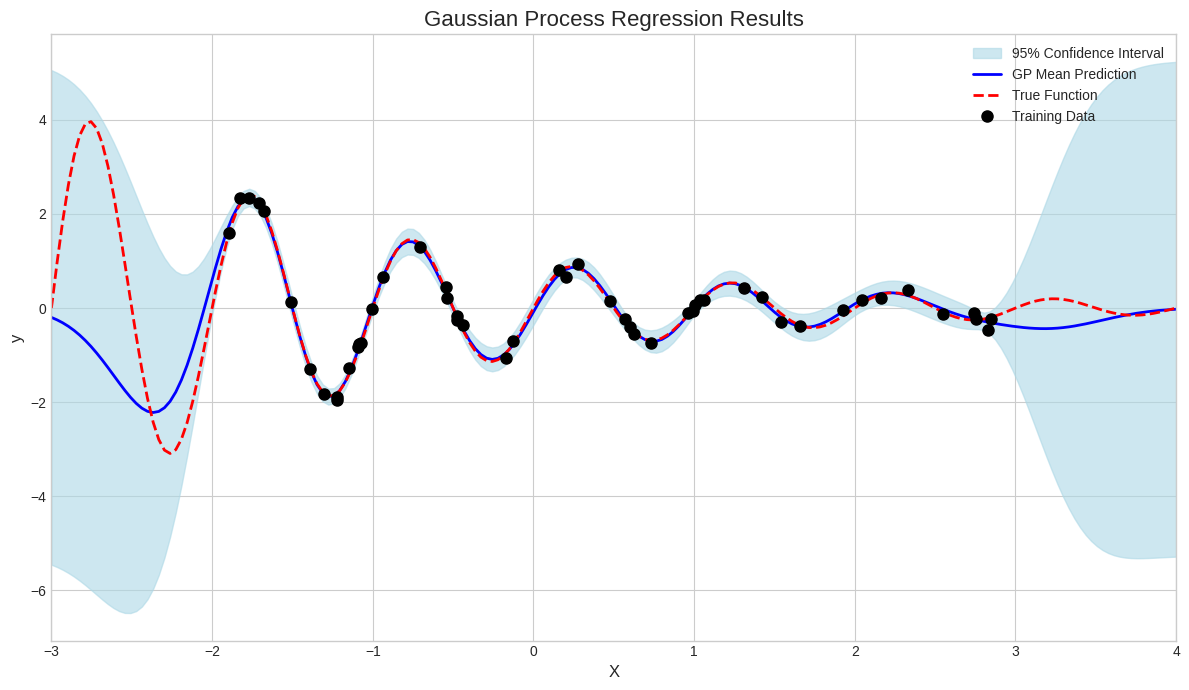

In [2]:
# In run_gpr.py

import logging
import numpy as np
import torch
import matplotlib.pyplot as plt


# --- Set up basic logging to see model output ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def main():
    """Main execution block for the GPR example."""

    # 1. Generate Synthetic Data
    # --------------------------
    # Set seeds for reproducibility
    np.random.seed(42)
    torch.manual_seed(42)

    # Define the true underlying function
    def true_function(x):
        return np.sin(x * 2 * np.pi) * np.exp(-x * 0.5)

    # Generate noisy training data
    N_train = 50
    X_train_np = np.random.uniform(-2.0, 3.0, N_train)
    y_train_np = true_function(X_train_np) + np.random.normal(scale=0.1, size=N_train)
    
    # Generate a grid of test points for smooth plotting
    N_test = 200
    X_test_np = np.linspace(-3.0, 4.0, N_test)
    y_test_np = true_function(X_test_np) # Ground truth for evaluation

    # Convert data to PyTorch tensors
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.float32)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.float32)

    # 2. Instantiate and Configure the GP Model
    # -----------------------------------------
    # Define how each hyperparameter should be optimized.
    # 'MLE' (Maximum Likelihood Estimation) is a common choice.
    hyper_settings = {
        'lengthscale': {'optim': 'MLE'},
        'outputscale': {'optim': 'MLE'},
        'noisescale':  {'optim': 'MLE'}
    }
    
    # Automatically select 'cuda' if available, otherwise 'cpu'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    logging.info(f"Using device: {device}")
    
    # Create an instance of the model
    model = GPR(X_train, y_train, kernel='rbf', hyper_settings=hyper_settings, device=device)

    # 3. Train the Model
    # -------------------
    # The fit method optimizes the hyperparameters by maximizing the marginal log-likelihood.
    history = model.fit(epochs=150, lr=0.05, X_test=X_test, y_test=y_test, eval_interval=25)

    # 4. Make Predictions
    # --------------------
    # The predict method returns the posterior mean and variance for the test points.
    mu_pred, var_pred = model.predict(X_test)
    std_pred = np.sqrt(var_pred.clip(min=0)) # Ensure variance is non-negative

    # 5. Print Final Hyperparameters
    # -------------------------------
    print("\n--- Final Optimized Hyperparameters ---")
    final_params = model._get_hyperparams()
    for name, val in final_params.items():
        print(f"{name}: {val.detach().cpu().numpy()}")
    
    # 6. Plot the Results
    # --------------------
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot the 95% confidence interval (mean +/- 2 standard deviations)
    ax.fill_between(
        X_test_np,
        mu_pred - 2 * std_pred,
        mu_pred + 2 * std_pred,
        color='lightblue',
        alpha=0.6,
        label='95% Confidence Interval'
    )
    
    # Plot the mean prediction
    ax.plot(X_test_np, mu_pred, 'b-', lw=2, label='GP Mean Prediction')
    
    # Plot the true underlying function
    ax.plot(X_test_np, y_test_np, 'r--', lw=2, label='True Function')
    
    # Plot the noisy training data points
    ax.plot(X_train_np, y_train_np, 'ko', ms=8, label='Training Data')

    ax.set_title('Gaussian Process Regression Results', fontsize=16)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True)
    ax.set_xlim(-3, 4)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()

2025-09-16 02:06:09,381 - INFO - Initialized lengthscale (Optim mode: MLE): 1.0
2025-09-16 02:06:09,382 - INFO - Initialized outputscale (Optim mode: MLE): 1.0
2025-09-16 02:06:09,382 - INFO - Initialized noisescale (Optim mode: MLE): 0.1
2025-09-16 02:06:09,453 - INFO - SparseGPR model initialized on device: cpu
2025-09-16 02:06:10,358 - INFO - Starting SVI optimization for 150 epochs...
2025-09-16 02:06:10,694 - INFO - Epoch   10/150 | Last ELBO: 54.050 | Test RMSE: 0.2274
2025-09-16 02:06:11,014 - INFO - Epoch   20/150 | Last ELBO: 105.898 | Test RMSE: 0.1768
2025-09-16 02:06:11,342 - INFO - Epoch   30/150 | Last ELBO: 184.246 | Test RMSE: 0.1613
2025-09-16 02:06:11,664 - INFO - Epoch   40/150 | Last ELBO: 142.453 | Test RMSE: 0.1276
2025-09-16 02:06:11,986 - INFO - Epoch   50/150 | Last ELBO: 201.452 | Test RMSE: 0.1419
2025-09-16 02:06:12,306 - INFO - Epoch   60/150 | Last ELBO: 130.368 | Test RMSE: 0.1495
2025-09-16 02:06:12,626 - INFO - Epoch   70/150 | Last ELBO: 154.351 | Test


--- Final Optimized Hyperparameters ---
lengthscale: [0.54703121]
outputscale: 0.7702183237473994
noisescale: 0.03901003445128469


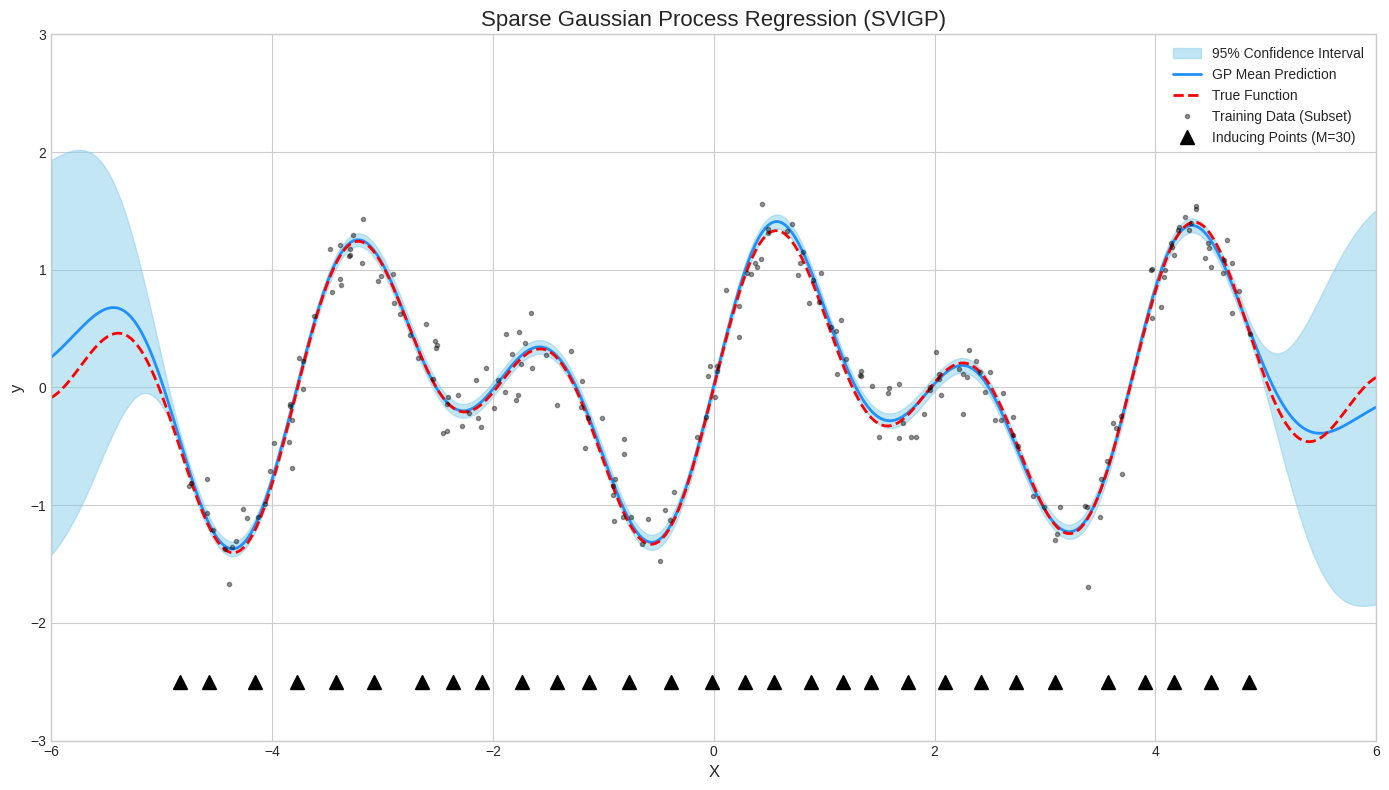

In [1]:
import logging
import math
import time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from linear_operator import to_linear_operator

from student.constants import EPSILON, JITTER
from student.kernels import rbf_kernel
from student.priors import GammaPrior

class SparseGPR(nn.Module):
    """
    Sparse Gaussian Process Regression (GPR) trained with Stochastic Variational Inference (SVI).

    This implementation refactors the original SVIGP logic into a more structured
    class format, separating hyperparameter initialization, E-step, M-step,
    and the main training loop for improved clarity and extensibility.
    """
    def __init__(
        self,
        X, y, M,
        hyper_settings=None,
        kernel="rbf",
        inducing_init_method="kmeans",
        device=None
    ):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        # Register data as non-trainable buffers
        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        self.dtype = self.X_full.dtype

        # Priors for hyperparameters
        self.lengthscale_prior = GammaPrior(1.0, 1.0)
        self.outputscale_prior = GammaPrior(2.0, 2.0)
        self.noisescale_prior = GammaPrior(2.0, 2.0)

        # Initialize hyperparameters
        hyperparameters = self._initialize_hyperparameters(hyper_settings)
        lengthscale = hyperparameters['lengthscale']
        outputscale = hyperparameters['outputscale']
        noisescale = hyperparameters['noisescale']

        # Register hyperparameters as learnable parameters
        self.log_lengthscale = nn.Parameter(torch.log(lengthscale))
        self.log_outputscale = nn.Parameter(torch.log(outputscale))
        self.log_noisescale = nn.Parameter(torch.log(noisescale))

        # Initialize inducing points as learnable parameters
        self.Z = nn.Parameter(self._initialize_inducing_points(method=inducing_init_method))

        # Register variational parameters for q(u) ~ N(m_u, S_u)
        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=self.dtype))
        # Storing L_u (Cholesky of S_u) for stability, as in the original logic
        self.register_buffer('L_u', torch.eye(self.M, dtype=self.dtype))

        # Set kernel function
        if kernel == "rbf":
            self.kernel = rbf_kernel
        else:
            raise NotImplementedError(f"Kernel '{kernel}' is not implemented.")

        self.to(self.device)
        logging.info(f"SparseGPR model initialized on device: {self.device}")

    def _initialize_hyperparameters(self, hyper_settings=None):
        self.hyper_optim_mode = {}
        dtype = self.dtype

        param_configs = {
            'lengthscale': {'prior': self.lengthscale_prior, 'is_vector': True},
            'outputscale': {'prior': self.outputscale_prior, 'is_vector': False},
            'noisescale': {'prior': self.noisescale_prior, 'is_vector': False},
        }
        initialized_params = {}

        for name, config in param_configs.items():
            settings = (hyper_settings or {}).get(name, {})
            mode = settings.get("optim", "MLE")
            init_val = settings.get("init", None)
            if mode not in ['MLE', 'MAP', 'FIX']: raise ValueError(f"Invalid mode '{mode}' for '{name}'.")
            self.hyper_optim_mode[name] = mode

            if init_val is None:
                sample_shape = (self.D,) if config['is_vector'] else torch.Size([])
                final_value = config['prior'].sample(sample_shape=sample_shape).to(self.device, dtype=dtype)
            else:
                final_value = init_val
            initialized_params[name] = torch.as_tensor(final_value, dtype=dtype, device=self.device)
            logging.info(f"Initialized {name} (Optim mode: {mode}): {initialized_params[name].cpu().numpy()}")

        ls = initialized_params['lengthscale']
        if ls.ndim == 0: ls = ls.repeat(self.D)
        if ls.shape[0] != self.D: raise ValueError("lengthscale must be scalar or vector of length D")
        initialized_params['lengthscale'] = ls
        return initialized_params

    def _initialize_inducing_points(self, method="kmeans"):
        if self.N >= self.M:
            if method == "kmeans":
                X_np = self.X_full.cpu().numpy()
                kmeans = KMeans(n_clusters=self.M, random_state=42, n_init='auto').fit(X_np)
                Z_init = torch.from_numpy(kmeans.cluster_centers_)
            elif method == "random":
                indices = np.random.choice(self.N, self.M, replace=False)
                Z_init = self.X_full[indices].clone()
            else: raise ValueError(f"Unknown init method: {method}")
        else:
            indices = np.random.choice(self.N, self.M, replace=True)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.dtype, device=self.device)

    def _get_hyperparams(self):
        return {
            "lengthscale": torch.exp(self.log_lengthscale),
            "outputscale": torch.exp(self.log_outputscale),
            "noisescale": torch.exp(self.log_noisescale)
        }

    def _calculate_log_prior(self, params):
        log_prior = torch.tensor(0.0, device=self.device, dtype=self.dtype)
        if self.hyper_optim_mode['lengthscale'] == 'MAP':
            log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        if self.hyper_optim_mode['outputscale'] == 'MAP':
            log_prior += self.outputscale_prior.log_prob(params['outputscale'])
        if self.hyper_optim_mode['noisescale'] == 'MAP':
            log_prior += self.noisescale_prior.log_prob(params['noisescale'])
        return log_prior

    def _calculate_elbo(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_hyperparams()
        beta = 1.0 / params['noisescale'].clamp(min=EPSILON)

        # --- Kernel Matrices ---
        K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
        # --- MODIFIED ---
        # Convert to LinearOperator and add jitter for stability
        K_mm_op = to_linear_operator(K_mm).add_jitter(JITTER)
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['outputscale'])

        # --- 1. Expected Log Likelihood Term ---
        S_u = self.L_u @ self.L_u.T
        # --- MODIFIED ---
        # A = K_mm^-1 @ K_mb using efficient solve
        A = K_mm_op.solve(K_mb)
        mu_b = A.T @ self.m_u # Expected value of f_batch

        E_sq_err = torch.sum((y_batch - mu_b)**2)
        k_bb_diag_sum = B * params['outputscale']
        psi_trace = torch.sum(A * K_mb)
        S_trace = torch.trace(A.T @ S_u @ A)
        var_f_sum = k_bb_diag_sum - psi_trace + S_trace
        
        log_lik_const = -0.5 * B * (math.log(2 * math.pi) - torch.log(beta))
        expected_log_likelihood = (log_lik_const - 0.5 * beta * (E_sq_err + var_f_sum)) * (self.N / B)

        # --- 2. KL Divergence KL(q(u) || p(u)) ---
        # --- MODIFIED ---
        # Using efficient methods from linear_operator for KL terms
        trace_kl = torch.trace(K_mm_op.solve(S_u))
        mahalanobis_kl = K_mm_op.inv_quad(self.m_u.squeeze(-1))
        log_det_Kmm = K_mm_op.logdet()
        log_det_Su = 2 * torch.sum(torch.log(self.L_u.diag().clamp(min=EPSILON)))
        log_det_kl = log_det_Kmm - log_det_Su

        kl_div = 0.5 * (trace_kl + mahalanobis_kl - self.M + log_det_kl)
        return expected_log_likelihood - kl_div

    @torch.no_grad()
    def _e_step(self, X_batch, y_batch, var_lr):
        B = X_batch.shape[0]
        params = self._get_hyperparams()
        beta = 1.0 / params['noisescale'].clamp(min=EPSILON)

        K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
        # --- MODIFIED ---
        K_mm_op = to_linear_operator(K_mm).add_jitter(JITTER)
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['outputscale'])

        # --- MODIFIED ---
        # Explicitly compute K_mm_inv tensor as it's needed for theta2_hat
        identity_M = torch.eye(self.M, device=self.device, dtype=self.dtype)
        K_mm_inv = K_mm_op.solve(identity_M)
        T = K_mm_inv @ K_mb

        # Calculate optimal natural parameters for the batch
        scaling = self.N / B
        theta2_hat = -0.5 * (K_mm_inv + beta * scaling * (T @ T.T))
        theta1_hat = beta * scaling * (T @ y_batch)

        # Get current natural parameters
        S_u = self.L_u @ self.L_u.T
        # --- MODIFIED ---
        # Invert S_u using linear_operator
        S_u_op = to_linear_operator(S_u).add_jitter(JITTER)
        S_u_inv = S_u_op.solve(identity_M)
        theta2_old = -0.5 * S_u_inv
        theta1_old = S_u_inv @ self.m_u

        # Polyak averaging
        theta2_new = (1 - var_lr) * theta2_old + var_lr * theta2_hat
        theta1_new = (1 - var_lr) * theta1_old + var_lr * theta1_hat

        # Convert back to standard parameters and update
        S_u_inv_new = -2 * theta2_new
        try:
            # --- MODIFIED ---
            # Invert S_u_inv_new using linear_operator
            S_u_inv_new_op = to_linear_operator(S_u_inv_new).add_jitter(JITTER)
            S_u_new = S_u_inv_new_op.solve(identity_M)
            m_u_new = S_u_new @ theta1_new
            L_u_new = torch.linalg.cholesky(S_u_new + JITTER * torch.eye(self.M, device=self.device, dtype=self.dtype))
            self.m_u.data.copy_(m_u_new)
            self.L_u.data.copy_(L_u_new)
        except torch.linalg.LinAlgError:
            logging.warning("Skipping E-step update due to non-positive definite matrix.")

    def _m_step(self, optimizer, loss):
        if optimizer is None: return
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    def fit(self, epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1,
            X_test=None, y_test=None, eval_interval=10):
        
        parameters_to_optimize = [
            p for name, p in self.named_parameters()
            if self.hyper_optim_mode.get(name.replace("log_", ""), "MLE") != 'FIX'
        ]
        
        optimizer = optim.Adam(parameters_to_optimize, lr=hyper_lr) if parameters_to_optimize else None
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {
            'elbo': [], 'log_prior': [], 'loss': [],
            'lengthscale': [], 'outputscale': [], 'noisescale': [],
            'eval_epochs': [], 'eval_metrics': [], 'fit_times': []
        }
        logging.info(f"Starting SVI optimization for {epochs} epochs...")

        for epoch in range(epochs):
            self.train()
            for X_batch, y_batch in dataloader:

                fit_start_time = time.time()

                self._e_step(X_batch, y_batch, var_lr=var_lr)
                elbo = self._calculate_elbo(X_batch, y_batch)
                log_prior = self._calculate_log_prior(self._get_hyperparams())
                loss = -(elbo + log_prior)
                self._m_step(optimizer, loss)

                fit_end_time = time.time()

                # --- Store history ---
                params_final = self._get_hyperparams()
                history['elbo'].append(elbo.item())
                history['log_prior'].append(log_prior.item())
                history['loss'].append(loss.item())
                history['lengthscale'].append(params_final['lengthscale'].detach().cpu().numpy())
                history['outputscale'].append(params_final['outputscale'].item())
                history['noisescale'].append(params_final['noisescale'].item())
                history['fit_times'].append(fit_end_time - fit_start_time)

            if (epoch + 1) % eval_interval == 0:
                log_msg = f"Epoch {epoch+1:4d}/{epochs} | Last ELBO: {elbo.item():.3f}"
                if X_test is not None and y_test is not None:
                    metrics = self._evaluate(X_test, y_test)
                    history['eval_epochs'].append(epoch + 1)
                    history['eval_metrics'].append(metrics)
                    log_msg += f" | Test RMSE: {metrics['rmse']:.4f}"
                logging.info(log_msg)
        
        logging.info("Optimization finished.")
        return history

    def predict(self, X_test):
        self.eval()
        X_test_dev = torch.as_tensor(X_test, dtype=self.dtype, device=self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        with torch.no_grad():
            params = self._get_hyperparams()
            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['outputscale'])
            # --- MODIFIED ---
            K_mm_op = to_linear_operator(K_mm).add_jitter(JITTER)
            K_sm = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['outputscale'])
            K_ss_diag = params['outputscale'] * torch.ones(X_test_dev.shape[0], device=self.device, dtype=self.dtype)
            
            # --- MODIFIED ---
            # A = K_sm @ K_mm^-1. More stable to compute via solve: (K_mm^-1 @ K_ms)^T
            A = K_mm_op.solve(K_sm.T).T
            
            pred_mean = A @ self.m_u
            
            S_u = self.L_u @ self.L_u.T
            var_term1 = K_ss_diag
            var_term2 = -torch.sum(A * K_sm, dim=1)
            var_term3 = torch.sum((A @ S_u) * A, dim=1)
            
            pred_var = var_term1 + var_term2 + var_term3
            return {
                'loc': pred_mean.cpu().squeeze(),
                'variance': pred_var.cpu().squeeze()
            }

    def _evaluate(self, X_test, y_test):
        self.eval()
        with torch.no_grad():
            pred_dict = self.predict(X_test)
            pred_mean = pred_dict['loc']
            y_true = y_test.cpu().view(-1)
            rmse = torch.sqrt(torch.mean((y_true - pred_mean)**2)).item()
        self.train()
        return {'rmse': rmse}

# =============================================================================
# Main Execution Block
# =============================================================================
def main():
    """Main execution block for the Sparse GPR example."""
    # 1. Generate Synthetic Data
    np.random.seed(42)
    torch.manual_seed(42)
    torch.set_default_dtype(torch.float64)

    def true_function(x):
        return np.sin(x * 2.5) * np.cos(x * 0.8) * 1.5

    N_train = 1000
    X_train_np = np.random.uniform(-5.0, 5.0, N_train)
    y_train_np = true_function(X_train_np) + np.random.normal(scale=0.2, size=N_train)
    
    N_test = 400
    X_test_np = np.linspace(-6.0, 6.0, N_test)
    y_test_np = true_function(X_test_np)

    X_train = torch.from_numpy(X_train_np)
    y_train = torch.from_numpy(y_train_np)
    X_test = torch.from_numpy(X_test_np)
    y_test = torch.from_numpy(y_test_np)

    # 2. Instantiate and Configure the Sparse GP Model
    M = 30  # Number of inducing points

    hyper_config = {
        'lengthscale': {'init': 1.0, 'optim': 'MLE'},
        'outputscale': {'init': 1.0, 'optim': 'MLE'},
        'noisescale': {'init': 0.1, 'optim': 'MLE'},
    }

    model = SparseGPR(X_train, y_train, M=M, hyper_settings=hyper_config)

    # 3. Train the Model
    history = model.fit(
        epochs=150,
        batch_size=256,
        hyper_lr=0.01,
        var_lr=0.1,
        X_test=X_test,
        y_test=y_test,
        eval_interval=10
    )

    # 4. Make Predictions
    pred_dict = model.predict(X_test)
    mu_pred = pred_dict['loc'].numpy()
    var_pred = pred_dict['variance'].numpy()
    std_pred = np.sqrt(var_pred.clip(min=0))
    inducing_points = model.Z.detach().cpu().numpy()

    # 5. Print Final Hyperparameters
    print("\n--- Final Optimized Hyperparameters ---")
    final_params = model._get_hyperparams()
    for name, val in final_params.items():
        print(f"{name}: {val.detach().cpu().numpy()}")
    
    # 6. Plot the Results
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 8))

    ax.fill_between(
        X_test_np, mu_pred - 1.96 * std_pred, mu_pred + 1.96 * std_pred,
        color="skyblue", alpha=0.5, label="95% Confidence Interval"
    )
    ax.plot(X_test_np, mu_pred, color="dodgerblue", lw=2, label="GP Mean Prediction")
    ax.plot(X_test_np, y_test_np, 'r--', lw=2, label="True Function")
    
    subset_indices = np.random.choice(N_train, 200, replace=False)
    ax.plot(
        X_train_np[subset_indices], y_train_np[subset_indices],
        'o', color='black', ms=3, alpha=0.4, label="Training Data (Subset)"
    )

    ax.plot(
        inducing_points, -2.5 * np.ones_like(inducing_points),
        'k^', ms=10, label=f"Inducing Points (M={M})"
    )

    ax.set_title("Sparse Gaussian Process Regression (SVIGP)", fontsize=16)
    ax.set_xlabel("X", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-3, 3)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()